In [5]:
import matplotlib.pyplot as plt
import dask.array as da
from skimage.measure import label
import tifffile
import skimage as ski
import pandas as pd
import os
import numpy as np
from scipy import ndimage as ndi

In [6]:
# read in image
root = "/yoren62/users/hannahbolen/immunofluorescence/slidescan_20250723_o8_gH2AX/full_res"
img_name = "o8p_day7_s12.ome.tif"
img_path = os.path.join(root, img_name)
img = tifffile.imread(img_path, aszarr=True)
img = da.from_zarr(img)

In [7]:
# constants
gfp_intensity = (256, 6000)
cy5_intensity = (256, 6000)
nuclei = img[0]
cy5 = img[1]
ds = 10
# create downsampled images
nuclei_ds = nuclei[::ds,::ds]
cy5_ds = cy5[::ds,::ds]

In [8]:
# make tile from center of full resolution image
# define constants
H, W = nuclei.shape
l = 512*10
y0 = H//2 - l//2
x0 = W//2 - l//2

# make tile with both image channels
nucleiTile = nuclei[y0:y0+l, x0:x0+l]
cy5Tile = cy5[y0:y0+l, x0:x0+l]

# make downsampled tiles for both image channels
nucleiTile_ds = nucleiTile[::ds,::ds]
cy5Tile_ds = cy5Tile[::ds,::ds]

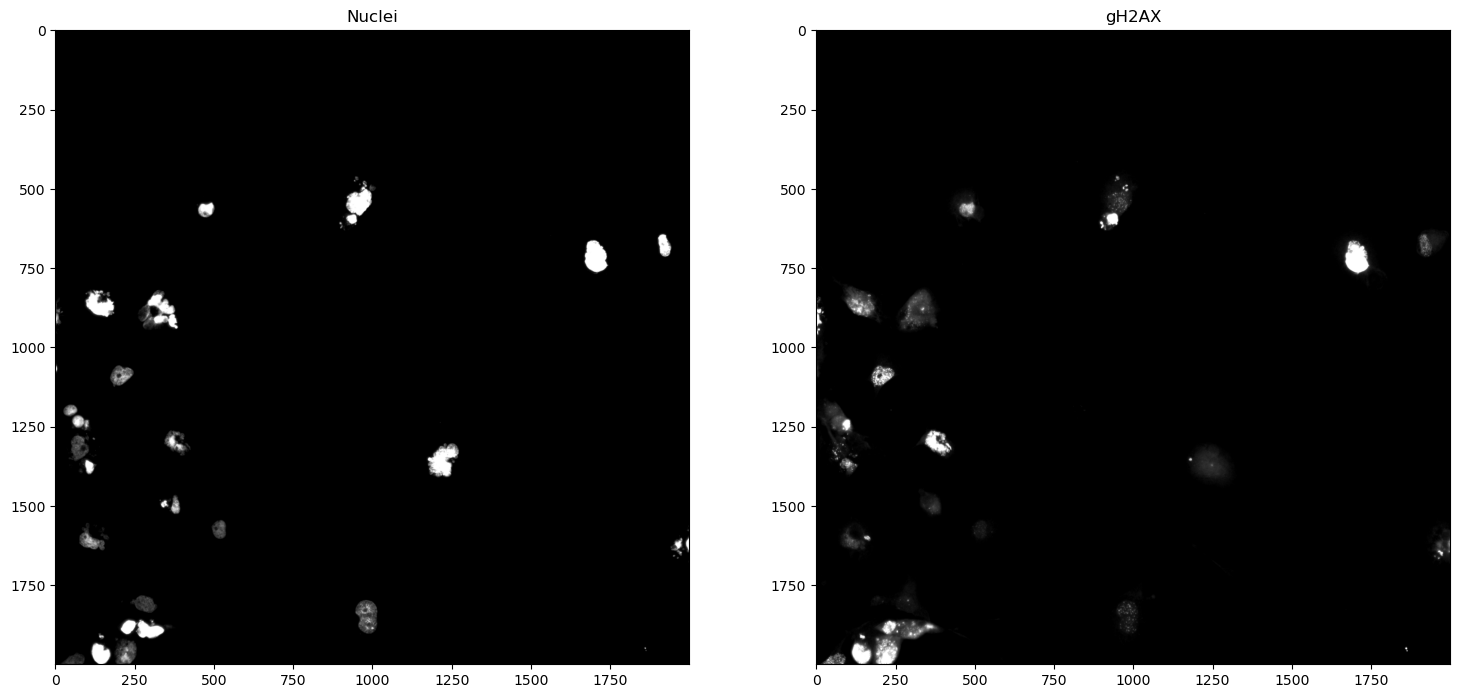

In [9]:
fullRes = True
zoom = True
# plot downsampled tiles
fig, ax = plt.subplots(ncols = 2, figsize = (18, 18))
if fullRes:
    if zoom:
        ax[0].imshow(ski.exposure.rescale_intensity(nucleiTile[1000:3000, 2000:4000], in_range = gfp_intensity), cmap = "gray")
        ax[1].imshow(ski.exposure.rescale_intensity(cy5Tile[1000:3000, 2000:4000], in_range = cy5_intensity), cmap="gray")
    else:
        ax[0].imshow(ski.exposure.rescale_intensity(nucleiTile, in_range = gfp_intensity), cmap = "gray")
        ax[1].imshow(ski.exposure.rescale_intensity(cy5Tile, in_range = cy5_intensity), cmap="gray")
else:
    if zoom:
        ax[0].imshow(ski.exposure.rescale_intensity(nucleiTile_ds[1000:3000, 2000:4000], in_range = gfp_intensity), cmap = "gray")
        ax[1].imshow(ski.exposure.rescale_intensity(cy5Tile_ds[1000:3000, 2000:4000], in_range = cy5_intensity), cmap="gray")
    else:
        ax[0].imshow(ski.exposure.rescale_intensity(nucleiTile_ds, in_range = gfp_intensity), cmap = "gray")
        ax[1].imshow(ski.exposure.rescale_intensity(cy5Tile_ds, in_range = cy5_intensity), cmap="gray")
ax[0].set_title("Nuclei")
ax[1].set_title("gH2AX")
plt.show()

In [15]:
# redo thresholding using adaptive otsu
# calculate threshold on SMOOTHED full resolution nuclei tile
# constants
radius = 150
neighborhood = ski.morphology.disk(radius)
# smooth and calculate local otsu threshold, convert to 8 bit
nucleiTile_rescale = ski.exposure.rescale_intensity(nucleiTile, in_range = gfp_intensity)
smoothNucleiTile_13 = ski.util.img_as_ubyte(ski.filters.gaussian(nucleiTile_rescale, sigma = 1.3))
local_otsu_13 = ski.filters.rank.otsu(smoothNucleiTile_13, neighborhood)

In [ ]:
# mask and fill, assess thresholding with full resolution nuclei tile
# set minimum threshold
min_threshold = 100
local_otsu_adj_13 = np.maximum(local_otsu_13, min_threshold)
mask_localNucleiTile_13 = smoothNucleiTile_13 >= local_otsu_adj_13
mask_localFillNucleiTile_13 = ndi.binary_fill_holes(mask_localNucleiTile_13)
nucleiTile_masked = nucleiTile_rescale*mask_localFillNucleiTile_13

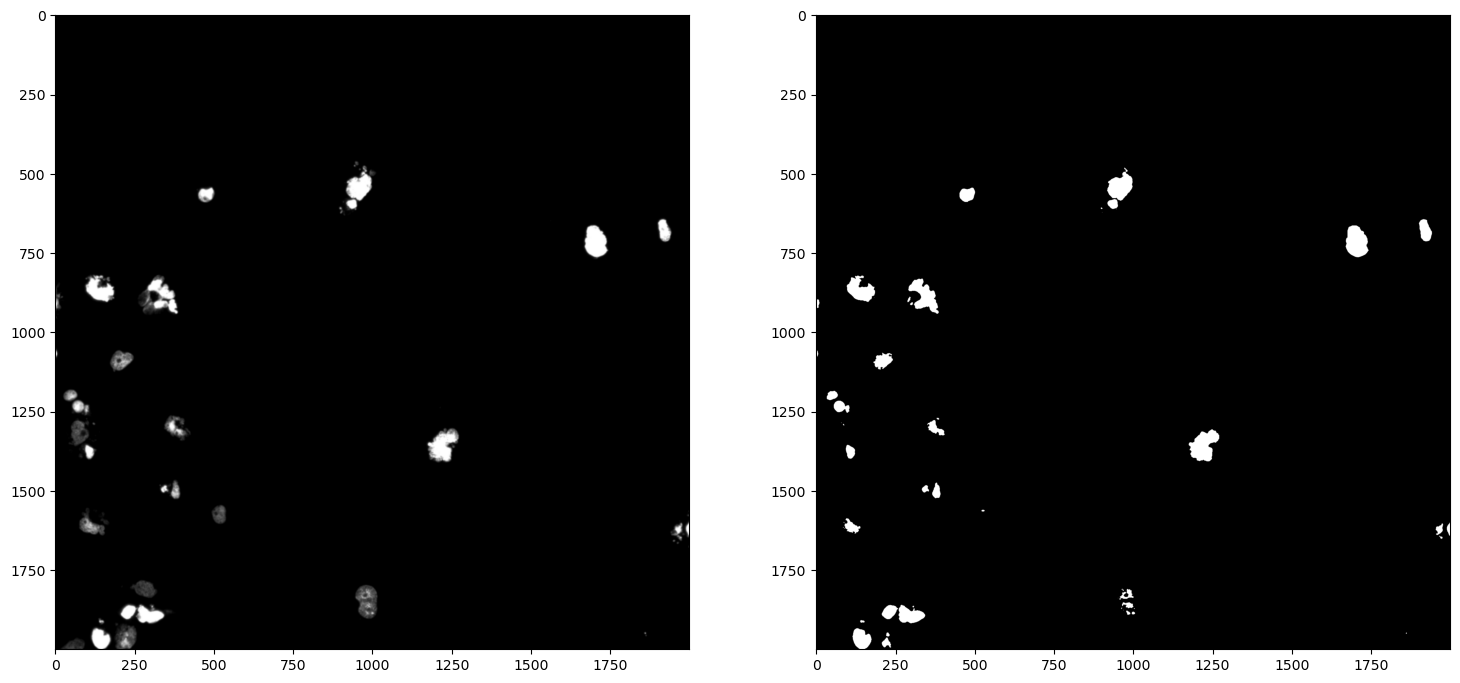

In [ ]:
# plot mask and full resolution nuclei tile, assess local otsu thresholding
zoom = False
fig, ax = plt.subplots(ncols = 2, figsize = (18, 18))
if zoom:
    ax[0].imshow(smoothNucleiTile_13[1000:3000, 2000:4000], cmap = "gray")
    ax[1].imshow(mask_localFillNucleiTile_13[1000:3000, 2000:4000], cmap="gray")
else:
    ax[0].imshow(smoothNucleiTile_13, cmap = "gray")
    ax[1].imshow(mask_localFillNucleiTile_13, cmap="gray")
plt.show()

In [ ]:
# save mask
mask_file = "".join([img_path.split(".")[0], "_maskFINAL.tif"])
img_dtype = tifffile.TiffFile(img_path).pages[0].dtype
tifffile.imwrite(mask_file, mask_localFillNucleiTile_13.astype(img_dtype))
# save tile
tile_file = "".join([img_path.split(".")[0], "_tile.tif"])
tifffile.imwrite(tile_file, nucleiTile.astype(img_dtype))

In [ ]:
mask_localFillNucleiTile = tifffile.imread(mask_file, aszarr=True)
mask_localFillNucleiTile = da.from_zarr(mask_localFillNucleiTile)

In [ ]:
# rescale cy5 histogram, apply mask
cy5Tile_rescale = ski.exposure.rescale_intensity(cy5Tile, in_range = cy5_intensity)
cy5Tile_masked = cy5Tile_rescale*mask_localFillNucleiTile_13

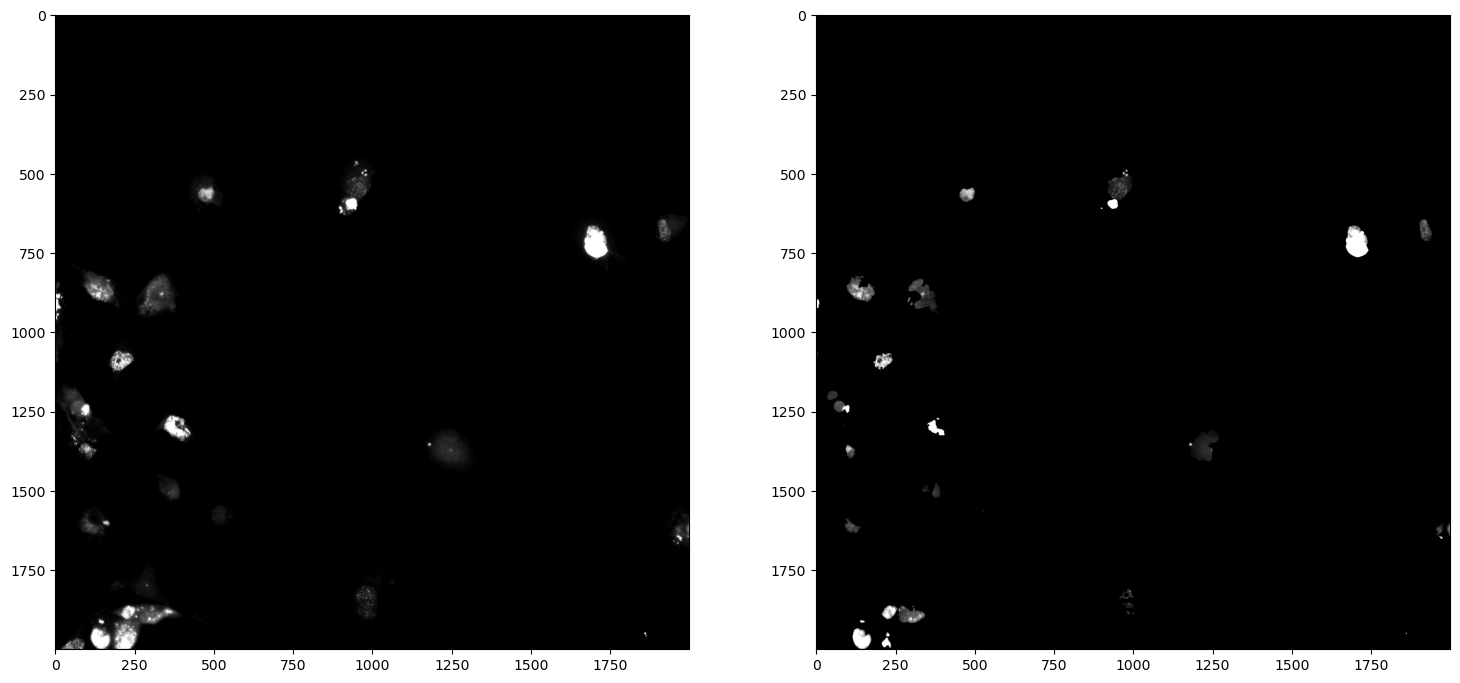

In [ ]:
# plot cy5 tile and masked cy5 tile
zoomCy5 = True
fig, ax = plt.subplots(ncols = 2, figsize = (18, 18))
if zoom:
    ax[0].imshow(cy5Tile_rescale[1000:3000, 2000:4000], cmap = "gray")
    ax[1].imshow(cy5Tile_masked[1000:3000, 2000:4000], cmap = "gray")
else:
    ax[0].imshow(cy5Tile_rescale, cmap = "gray")
    ax[1].imshow(cy5Tile_masked, cmap = "gray")
plt.show()

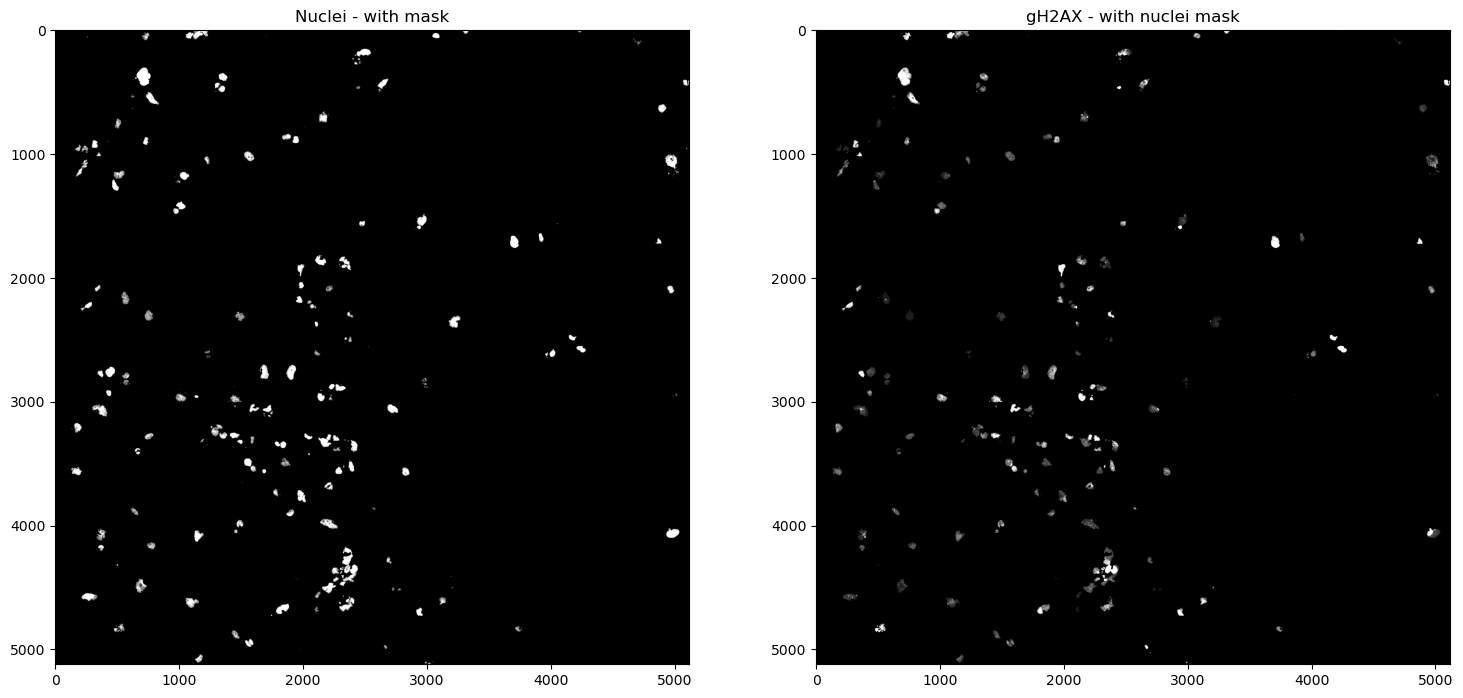

In [47]:
# plot mask and full resolution nuclei tile, assess local otsu thresholding
zoom = False
fig, ax = plt.subplots(ncols = 2, figsize = (18, 18))
if zoom:
    ax[0].imshow(nucleiTile_masked[1000:3000, 2000:4000], cmap = "gray")
    ax[1].imshow(cy5Tile_masked[1000:3000, 2000:4000], cmap = "gray")
else:
    ax[0].imshow(nucleiTile_masked, cmap = "gray")
    ax[1].imshow(cy5Tile_masked, cmap="gray")
ax[0].set_title("Nuclei - with mask")
ax[1].set_title("gH2AX - with nuclei mask")
plt.show()

In [63]:
# enhance features between 1 and 15 pixels, otsu threshold on DOG filtered image
dog_cy5Tile_rescale = ski.util.img_as_ubyte(ski.filters.difference_of_gaussians(cy5Tile_masked, low_sigma = .1, high_sigma = 7))
##threshold_dog = ski.filters.threshold_otsu(dog_cy5Tile_rescale)
##thresholded_dog_cy5Tile = dog_cy5Tile_rescale >= threshold_dog

# try thresholding gaussian bandpass filtered cy5 tile with local otsu threshold
radius_cy5dog = 9
neighborhood_cy5dog = ski.morphology.disk(radius_cy5dog)
localThreshold_dog = ski.filters.rank.otsu(dog_cy5Tile_rescale, neighborhood_cy5dog)


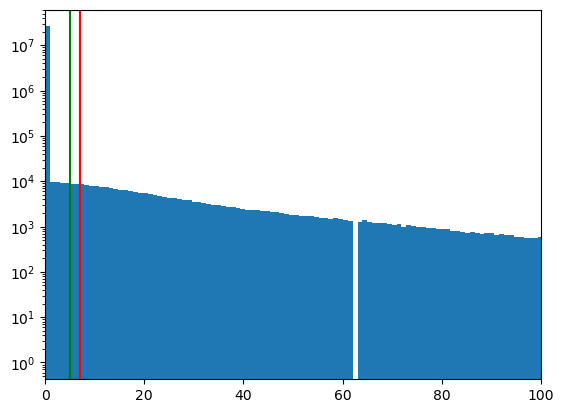

In [69]:
# determine minimum threshold for gH2AX masking
fig, ax = plt.subplots()
ax.hist(dog_cy5Tile_rescale.ravel(), bins = 255)
ax.set_yscale('log')
ax.set_xlim(0,100)
ax.axvline(7, color = 'r')
ax.axvline(5, color = 'g')
plt.show()

In [79]:
min_threshold_dog = 5
localThreshold_dogAdj = np.maximum(localThreshold_dog, min_threshold_dog)
cy5dog_mask_local = dog_cy5Tile_rescale >= localThreshold_dogAdj
dog_cy5Tile_masked = cy5Tile_masked*cy5dog_mask_local

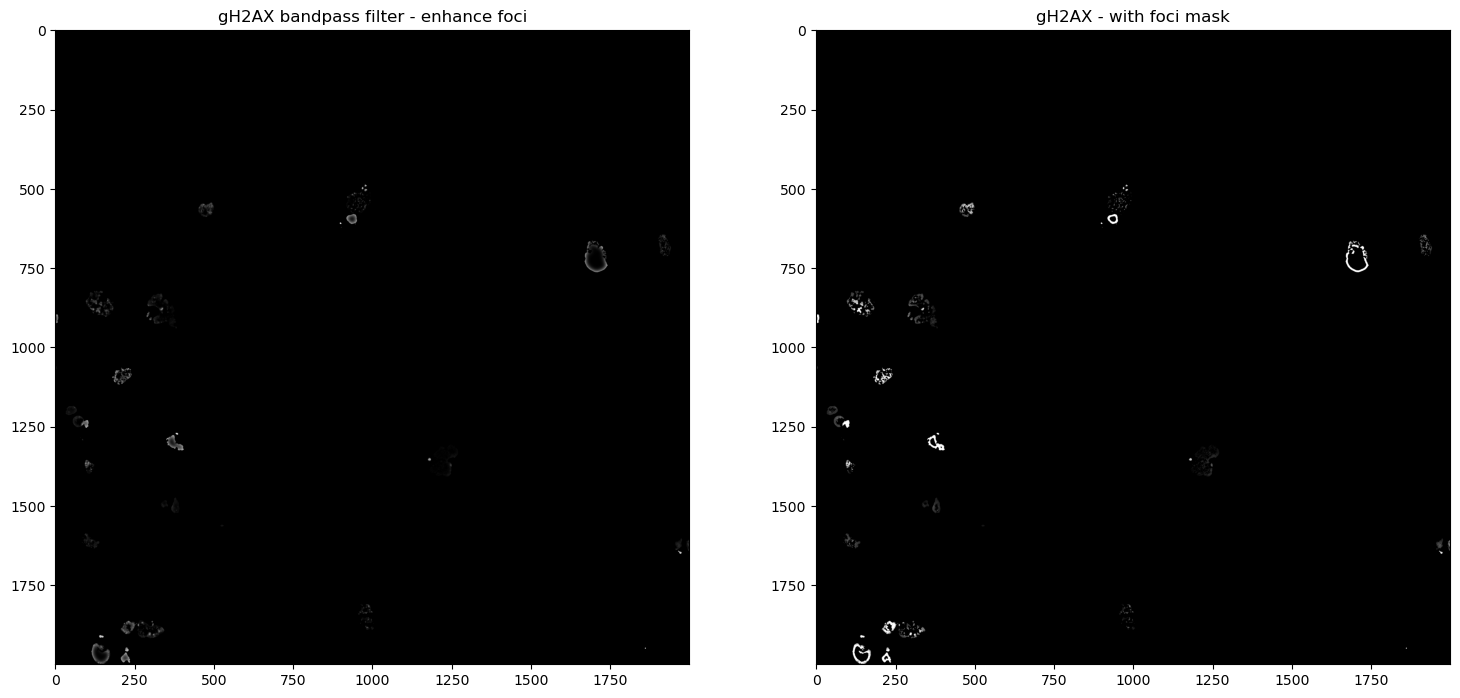

In [80]:
# plot cy5 tile and masked cy5 tile
zoomFoci = True
fig, ax = plt.subplots(ncols = 2, figsize = (18, 18))
if zoomFoci:
    ax[0].imshow(dog_cy5Tile_rescale[1000:3000, 2000:4000], cmap = "gray")
    ax[1].imshow(dog_cy5Tile_masked[1000:3000, 2000:4000], cmap = "gray")
else:
    ax[0].imshow(dog_cy5Tile_rescale, cmap = "gray")
    ax[1].imshow(dog_cy5Tile_masked, cmap = "gray")
ax[0].set_title("gH2AX bandpass filter - enhance foci")
ax[1].set_title("gH2AX - with foci mask")
plt.show()

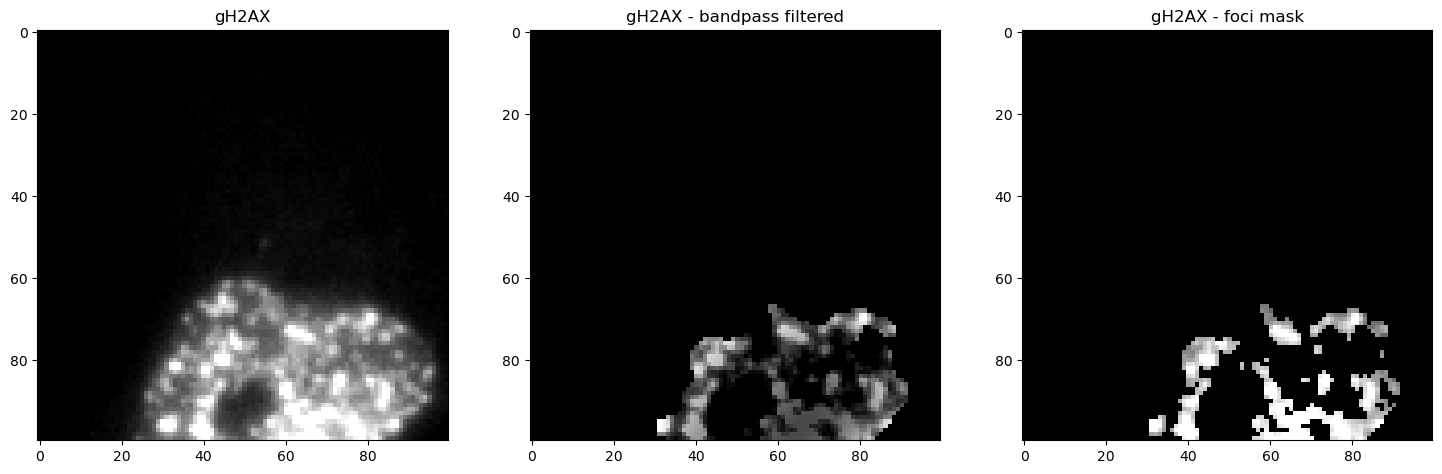

In [81]:
# plot cy5 tile and masked cy5 tile
fig, ax = plt.subplots(ncols = 3, figsize = (18, 18))
ax[0].imshow(cy5Tile_rescale[2000:2100, 2150:2250], cmap = "gray")
ax[0].set_title("gH2AX")
ax[1].imshow(dog_cy5Tile_rescale[2000:2100, 2150:2250], cmap = "gray")
ax[1].set_title("gH2AX - bandpass filtered")
ax[2].imshow(dog_cy5Tile_masked[2000:2100, 2150:2250], cmap = "gray")
ax[2].set_title("gH2AX - foci mask")
plt.show()

In [ ]:
fullres = True
zoom = True
fig, ax = plt.subplots(ncols = 3, figsize = (18, 18))
if fullres:
        if zoom:
                ax[0].imshow(ski.exposure.rescale_intensity(nucleiTile[1000:3000, 2000:4000], in_range = gfp_intensity), cmap = "gray")
                ax[1].imshow(ski.exposure.rescale_intensity(cy5Tile[1000:3000, 2000:4000], in_range = cy5_intensity), cmap="gray")
        else:
                ax[0].imshow(ski.exposure.rescale_intensity(nucleiTile, in_range = gfp_intensity), cmap = "gray")
                ax[1].imshow(ski.exposure.rescale_intensity(cy5Tile, in_range = cy5_intensity), cmap="gray")
else:
        if zoom:
                ax[0].imshow(ski.exposure.rescale_intensity(nucleiTile_ds[1000:3000, 2000:4000], in_range = gfp_intensity), cmap = "gray")
                ax[1].imshow(ski.exposure.rescale_intensity(cy5Tile_ds[1000:3000, 2000:4000], in_range = cy5_intensity), cmap="gray")
        else:
                ax[0].imshow(ski.exposure.rescale_intensity(nucleiTile_ds, in_range = gfp_intensity), cmap = "gray")
                ax[1].imshow(ski.exposure.rescale_intensity(cy5Tile_ds, in_range = cy5_intensity), cmap="gray")
plt.show()


In [17]:
# calculate threshold on downsampled nuclei tile
# thresholdOtsu = ski.filters.threshold_otsu(nucleiTile_ds)

# calculate threshold on SMOOTHED downsampled nuclei tile
smoothNucleiTile_ds = ski.filters.gaussian(nucleiTile_ds, sigma = 0.5)
smoothThresholdOtsu_ds = ski.filters.threshold_otsu(smoothNucleiTile_ds)
# mask and fill, assess thresholding with downsampled nuclei tile
mask_smoothNucleiTile_ds = smoothNucleiTile_ds >= smoothThresholdOtsu_ds
mask_smoothFillNuclei_ds = ndi.binary_fill_holes(mask_smoothNucleiTile_ds)
# plot mask and downsampled nuclei tile, assess thresholding
fig, ax = plt.subplots(ncols = 2, figsize = (18, 18))
ax[0].imshow(ski.exposure.rescale_intensity(nucleiTile_ds, in_range = gfp_intensity), cmap = "gray")
ax[1].imshow(mask_smoothFillNuclei_ds, cmap="gray")
plt.show()

In [25]:
# # calculate threshold on SMOOTHED full resolution nuclei tile
# nucleiTile_rescale = ski.exposure.rescale_intensity(nucleiTile, in_range = gfp_intensity)
# smoothNucleiTile = ski.filters.gaussian(nucleiTile, sigma = 0.75)
# smoothThresholdOtsu = ski.filters.threshold_otsu(smoothNucleiTile)
# # mask and fill, assess thresholding with downsampled nuclei tile
# mask_smoothNucleiTile = smoothNucleiTile >= smoothThresholdOtsu
# mask_smoothFillNuclei = ndi.binary_fill_holes(mask_smoothNucleiTile)

# calculate threshold on SMOOTHED histogram rescaled nuclei tile
nucleiTile_rescale = ski.exposure.rescale_intensity(nucleiTile, in_range = gfp_intensity)
smoothNucleiTile = ski.filters.gaussian(nucleiTile_rescale, sigma = 0.75)
smoothThresholdOtsu = ski.filters.threshold_otsu(smoothNucleiTile)
# mask and fill, assess thresholding with downsampled nuclei tile
mask_smoothNucleiTile = smoothNucleiTile >= smoothThresholdOtsu
mask_smoothFillNuclei = ndi.binary_fill_holes(mask_smoothNucleiTile)
fig, ax = plt.subplots()
ax.hist(smoothNucleiTile.ravel(), bins = 255)
ax.axvline(smoothThresholdOtsu, color = 'r')
plt.yscale('log')
plt.show()
# plot mask and full resolution nuclei tile, assess thresholding
fig, ax = plt.subplots(ncols = 2, figsize = (18, 18))
ax[0].imshow(ski.exposure.rescale_intensity(nucleiTile, in_range = gfp_intensity), cmap = "gray")
ax[1].imshow(mask_smoothFillNuclei, cmap="gray")
plt.show()
# save mask
mask_file = "".join([img_path.split(".")[0], "_maskv2.tif"])
img_dtype = tifffile.TiffFile(img_path).pages[0].dtype
tifffile.imwrite(mask_file, mask_smoothFillNuclei.astype(img_dtype))